# Project 1: Numerical Methods for ODEs #

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Problem A: Smooth Test Problem

In [37]:
def f(t, y):
    return y - t**2 + 1
def exact(t):
    return (t+1)**2 - 0.5*np.exp(t)

t0 = 0
T = 2
y0 = 0.5

### Method Definitions

In [38]:
def euler(f, t0, y0, T, h):
    n = int((T-t0)/h)
    t = np.zeros(n+1)
    w = np.zeros(n+1)

    t[0] = t0
    w[0] = y0

    for i in range(n):
        t[i+1] = t[i] + h
        w[i+1] = w[i] + h*f(t[i], w[i])

    return t, w

In [16]:
def midpoint(f, t0, y0, T, h):
    n = int((T-t0)/h)
    t = np.zeros(n+1)
    w = np.zeros(n+1)
    t[0] = t0
    w[0] = y0

    for i in range(n):
        t[i+1] = t[i] + h
        k1 = f(t[i], w[i])
        k2 = f(t[i] + h/2, w[i] + h*k1/2)
        w[i+1] = w[i] + h*k2

    return t, w

In [28]:
def heun(f, t0, y0, T, h):
    n = int((T-t0) / h)
    t = np.zeros(n+1)
    w = np.zeros(n+1)

    t[0] = t0
    w[0] = y0
    for i in range(n):
        t[i+1] = t[i] + h
        k1 = f(t[i], w[i])
        k2 = f(t[i] + h, w[i] + h*k1)

        w[i+1] = w[i] + h*(k1 + k2)/2
    return t, w

In [29]:
def rk4(f, t0, y0, T, h):
    n = int((T-t0)/h)
    t = np.zeros(n+1)
    w = np.zeros(n+1)

    t[0] = t0
    w[0] = y0

    for i in range(n):
        t[i+1] = t[i] + h
        k1 = f(t[i], w[i])
        k2 = f(t[i] + h/2, w[i] + h*k1/2)
        k3 = f(t[i] + h/2, w[i] + h*k2/2)
        k4 = f(t[i] + h, w[i] + h*k3)

        w[i+1] = w[i] + h*(k1 + 2*k2 + 2*k3 + k4)/6
        
    return t,w

In [57]:
def taylor2(t0, y0, T, h):
    n = int((T - t0)/h)
    t = np.zeros(n+1)
    w = np.zeros(n+1)

    t[0] = t0
    w[0] = y0

    for i in range(n):
        t[i+1] = t[i] + h
        yp = w[i] - t[i]**2 + 1
        ypp = w[i] - t[i]**2 + 1 - 2*t[i]
        w[i+1] = w[i] + h*yp + (h**2/2)*ypp

    return t,w

In [58]:
def adams_bashforth(f, t0, y0, T, h):
    n = int((T - t0)/h)
    t = np.zeros(n+1)
    w = np.zeros(n+1)

    t[0] = t0
    w[0] = y0

    k1 = f(t0, y0)
    k2 = f(t0+h/2, y0+h*k1/2)
    k3 = f(t0+h/2, y0+h*k2/2)
    k4 = f(t0+h, y0+h*k3)

    t[1] = t0+h
    w[1] = y0 + h*(k1+2*k2+2*k3+k4)/6

    for i in range(1,n):
        t[i+1] = t[i] + h
        fn = f(t[i],w[i])
        fnm1 = f(t[i-1],w[i-1])
        w[i+1] = w[i] + h*(3*fn-fnm1)/2

    return t,w

In [59]:
def adams_moulton(f, t0, y0, T, h, iterations=5):

    n = int((T - t0)/h)
    t = np.zeros(n+1)
    w = np.zeros(n+1)

    t[0] = t0
    w[0] = y0

    k1 = f(t0, y0)
    k2 = f(t0+h/2, y0+h*k1/2)
    k3 = f(t0+h/2, y0+h*k2/2)
    k4 = f(t0+h, y0+h*k3)

    t[1] = t0 + h
    w[1] = y0 + h*(k1 + 2*k2 + 2*k3 + k4)/6

    for i in range(1, n):
        t[i+1] = t[i] + h
        w_guess = w[i] + h*(3*f(t[i], w[i]) - f(t[i-1], w[i-1]))/2

        for j in range(iterations):
            w_guess = w[i] + h*(f(t[i+1], w_guess) + f(t[i], w[i]))/2
        w[i+1] = w_guess

    return t, w

In [60]:
def predictor_corrector(f, t0, y0, T, h):
    n = int((T - t0)/h)
    t = np.zeros(n+1)
    w = np.zeros(n+1)

    t[0] = t0
    w[0] = y0

    k1 = f(t0, y0)
    k2 = f(t0+h/2, y0+h*k1/2)
    k3 = f(t0+h/2, y0+h*k2/2)
    k4 = f(t0+h, y0+h*k3)

    t[1] = t0 + h
    w[1] = y0 + h*(k1 + 2*k2 + 2*k3 + k4)/6

    for i in range(1, n):
        t[i+1] = t[i] + h
        w_predict = w[i] + h*(3*f(t[i], w[i]) - f(t[i-1], w[i-1]))/2
        
        w[i+1] = w[i] + h*(f(t[i+1], w_predict) + f(t[i], w[i]))/2

    return t, w

### Exact & Numerical Solutions

In [61]:
## Implementation
h=0.2

t_eu, w_eu = euler(f, t0, y0, T, h)
t_mid, w_mid = midpoint(f, t0, y0, T, h)
t_heun, w_heun = heun(f, t0, y0, T, h)
t_rk4, w_rk4 = rk4(f, t0, y0, T, h)
t_tay, w_tay = taylor2(t0, y0, T, h)
t_ab, w_ab = adams_bashforth(f, t0, y0, T, h)
t_am, w_am = adams_moulton(f, t0, y0, T, h)
t_pc, w_pc = predictor_corrector(f, t0, y0, T, h)

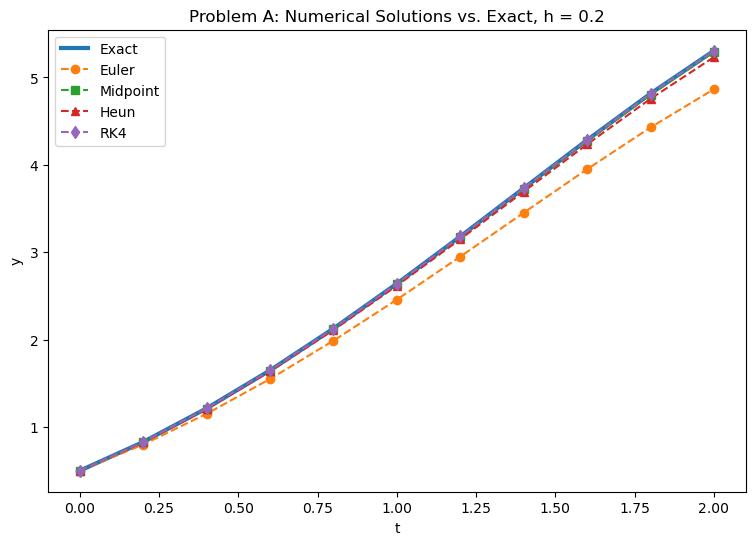

In [65]:
## Plotting
plt.figure(figsize=(9, 6))

plt.plot(t_eu, exact(t_eu), label="Exact", linewidth=3)
plt.plot(t_eu, w_eu, "o--", label="Euler")
plt.plot(t_mid, w_mid, "s--", label="Midpoint")
plt.plot(t_heun, w_heun, "^--", label="Heun")
plt.plot(t_rk4, w_rk4, "d--", label="RK4")

plt.xlabel("t")
plt.ylabel("y")
plt.title("Problem A: Numerical Solutions vs. Exact, h = 0.2")
plt.legend()
plt.show()

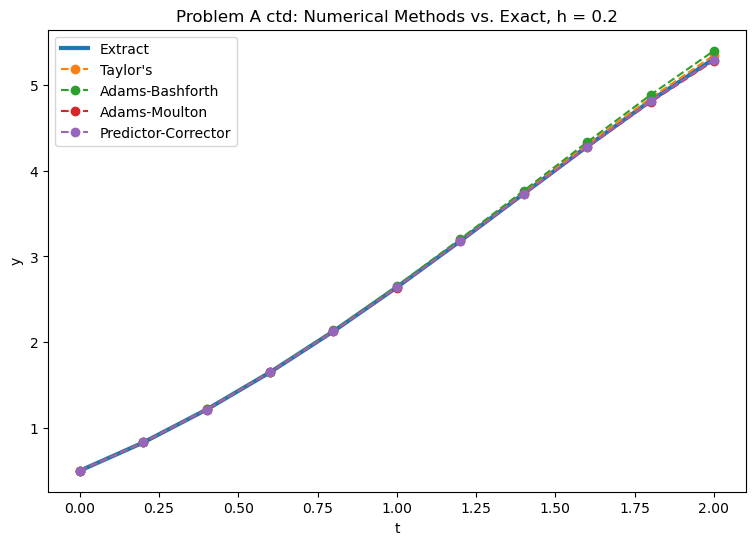

In [62]:
plt.figure(figsize=(9,6))
plt.plot(t_eu, exact(t_eu), linewidth=3, label="Exact")
plt.plot(t_tay, w_tay, "o--", label="Taylor's")
plt.plot(t_ab, w_ab, "o--", label="Adams-Bashforth")
plt.plot(t_am, w_am, "o--", label="Adams-Moulton")
plt.plot(t_pc, w_pc,"o--", label="Predictor-Corrector")

plt.xlabel("t")
plt.ylabel("y")
plt.title("Problem A ctd: Numerical Methods vs. Exact, h = 0.2")
plt.legend()
plt.show()

### Error Computation & Plots

In [67]:
def abs_error(exact, numerical):
    return np.abs(exact-numerical)
def max_error(exact, numerical):
    return np.max(np.abs(exact-numerical))

In [76]:
err_eu = abs_error(exact(t_eu), w_eu)
err_tay = abs_error(exact(t_tay), w_tay)
err_mid = abs_error(exact(t_mid), w_mid)
err_heun = abs_error(exact(t_heun), w_heun)
err_rk4 = abs_error(exact(t_rk4), w_rk4)
err_ab = abs_error(exact(t_ab), w_ab)
err_am = abs_error(exact(t_am), w_am)
err_pc = abs_error(exact(t_pc), w_pc)

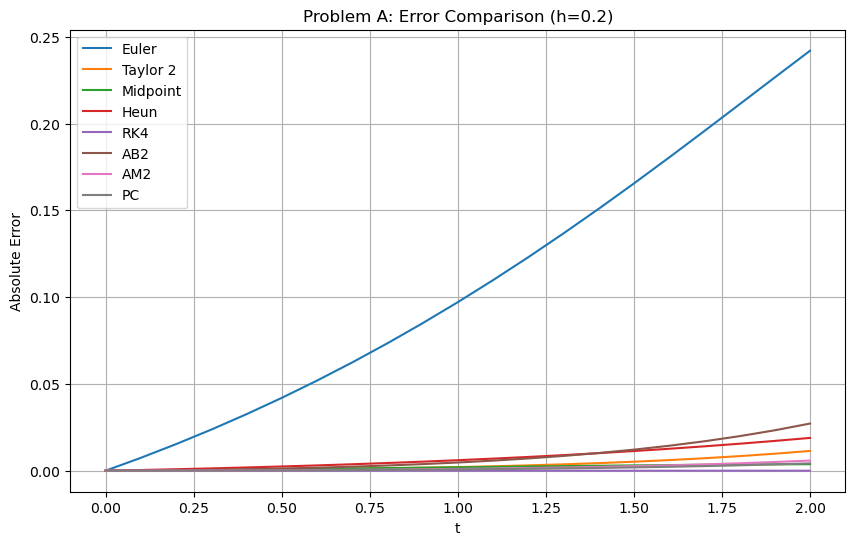

In [93]:
## Plotting
plt.figure(figsize=(10,6))

plt.plot(t_eu, err_eu, label='Euler')
plt.plot(t_tay, err_tay, label='Taylor 2')
plt.plot(t_mid, err_mid, label='Midpoint')
plt.plot(t_heun, err_heun, label='Heun')
plt.plot(t_rk4, err_rk4, label='RK4')
plt.plot(t_ab, err_ab, label='AB2')
plt.plot(t_am, err_am, label='AM2')
plt.plot(t_pc, err_pc, label='PC')

plt.xlabel('t')
plt.ylabel('Absolute Error')
plt.title('Problem A: Error Comparison (h=0.2)')
plt.legend()
plt.grid(True)

plt.show()

**Maximum Error Table**

In [95]:
h_values = [0.2, 0.1, 0.05]

methods = [
    ("Euler", euler),
    ("Taylor", taylor2),
    ("Midpoint", midpoint),
    ("Heun", heun),
    ("RK4", rk4),
    ("AB2", adams_bashforth),
    ("AM2", adams_moulton),
    ("Predictor-Corrector", predictor_corrector)
]

print(f"{'Method':<22} {'h = 0.2':>15} {'h = 0.1':>15} {'h = 0.05':>15}")
print("-" * 70)

for method_name, method in methods:
    row = f"{method_name:<22}"

    for h in h_values:
        if method_name == "Taylor":
            t, w = method(t0, y0, T, h)
        else:
            t, w = method(f, t0, y0, T, h)

        exact_values = exact(t)
        error = np.abs(exact_values - w)
        max_err = np.max(error)

        row += f"{max_err:15.6e}"

    print(row)

Method                         h = 0.2         h = 0.1        h = 0.05
----------------------------------------------------------------------
Euler                    4.396874e-01   2.419719e-01   1.274657e-01
Taylor                   4.221234e-02   1.141063e-02   2.964437e-03
Midpoint                 1.510249e-02   3.747074e-03   9.277142e-04
Heun                     7.241732e-02   1.890478e-02   4.819865e-03
RK4                      1.089498e-04   6.990307e-06   4.421339e-07
AB2                      9.373255e-02   2.718050e-02   7.257185e-03
AM2                      2.239965e-02   5.864208e-03   1.501807e-03
Predictor-Corrector      1.127415e-02   4.266544e-03   1.287299e-03


### Comparing Numerical Approximations (Euler & RK4)

(Using step size h=0.1)

**Euler Method**

In [90]:
print()
print(f"{'t':<8}{'Exact':<15}{'Euler':<15}{'Absolute Error':<15}")
print("-"*55)

for i in range(len(t_eu)):
    print(
        f"{t_eu[i]:<8.2f}"
        f"{exact(t_eu)[i]:<15.6f}"
        f"{w_eu[i]:<15.6f}"
        f"{err_eu[i]:<15.6e}"
    )


t       Exact          Euler          Absolute Error 
-------------------------------------------------------
0.00    0.500000       0.500000       0.000000e+00   
0.10    0.657415       0.650000       7.414541e-03   
0.20    0.829299       0.814000       1.529862e-02   
0.30    1.015071       0.991400       2.367060e-02   
0.40    1.214088       1.181540       3.254765e-02   
0.50    1.425639       1.383694       4.194536e-02   
0.60    1.648941       1.597063       5.187720e-02   
0.70    1.883124       1.820770       6.235391e-02   
0.80    2.127230       2.053847       7.338282e-02   
0.90    2.380198       2.295231       8.496706e-02   
1.00    2.640859       2.543755       9.710456e-02   
1.10    2.907917       2.798130       1.097870e-01   
1.20    3.179942       3.056943       1.229986e-01   
1.30    3.455352       3.318637       1.367144e-01   
1.40    3.732400       3.581501       1.508990e-01   
1.50    4.009155       3.843651       1.655044e-01   
1.60    4.283484       4.

**RK4 Method**

In [92]:
print(f"{'t':<8}{'Exact':<15}{'RK4':<15}{'Abs Error':<15}")
print("-"*55)

for i in range(len(t_rk4)):
    print(
        f"{t_rk4[i]:<8.2f}"
        f"{exact(t_rk4)[i]:<15.6f}"
        f"{w_rk4[i]:<15.6f}"
        f"{err_rk4[i]:<15.6e}"
    )

t       Exact          RK4            Abs Error      
-------------------------------------------------------
0.00    0.500000       0.500000       0.000000e+00   
0.10    0.657415       0.657414       1.659622e-07   
0.20    0.829299       0.829298       3.449225e-07   
0.30    1.015071       1.015070       5.377794e-07   
0.40    1.214088       1.214087       7.454764e-07   
0.50    1.425639       1.425638       9.690017e-07   
0.60    1.648941       1.648939       1.209388e-06   
0.70    1.883124       1.883122       1.467708e-06   
0.80    2.127230       2.127228       1.745076e-06   
0.90    2.380198       2.380196       2.042642e-06   
1.00    2.640859       2.640857       2.361585e-06   
1.10    2.907917       2.907914       2.703112e-06   
1.20    3.179942       3.179938       3.068444e-06   
1.30    3.455352       3.455348       3.458811e-06   
1.40    3.732400       3.732396       3.875438e-06   
1.50    4.009155       4.009151       4.319531e-06   
1.60    4.283484       4.2